In [23]:
## tools

from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_community.tools.semanticscholar.tool import SemanticScholarQueryRun
from langchain_community.utilities.semanticscholar import SemanticScholarAPIWrapper
import time


In [24]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Query arxiv papers")
print(arxiv.name)

arxiv


In [25]:
api_wrapper_semantic = SemanticScholarAPIWrapper(top_k_results=2, doc_content_chars_max=500)
semantic_scholar = SemanticScholarQueryRun(api_wrapper=api_wrapper_semantic)
print(semantic_scholar.name)

semanticscholar


In [26]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wikipedia = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wikipedia.name)

wikipedia


In [27]:
# arxiv.invoke("attention is all you need")

# semantic_scholar.invoke("attention is all you need")

wikipedia.invoke("attention is all you need")

'Page: Attention Is All You Need\nSummary: "Attention Is All You Need" is a 2017 research paper on machine learning authored by eight scientists and engineers working at Google. The paper introduced a new deep learning architecture known as the transformer, based on the attention mechanism proposed in 2014 by Bahdanau et al. The transformer approach it describes has become the main architecture of a wide variety of artificial intelligence systems, including large language models. At the time, the '

In [28]:
from dotenv import load_dotenv
load_dotenv()


import os
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [29]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [30]:
tavily.invoke("what is the latest research on quantum computing?")

[{'title': 'World Quantum Day 2024: The latest developments in quantum science and technology | PME | The University of Chicago',
  'url': 'https://pme.uchicago.edu/news-events/news/world-quantum-day-2024-latest-developments-quantum-science-and-technology',
  'content': 'Researchers at UChicago Pritzker Molecular Engineering, including Chicago Quantum Exchange IBM postdoctoral scholar Junyu Liu, and collaborators show in a new paper how incorporating quantum computing into the classical machine learning process can potentially help make machine learning more sustainable and efficient.\n\n Learn how quantum computing will affect artificial intelligence\n\nIn novel quantum computer design, qubits use magnets to selectively communicate\n\nAn international team of researchers have begun to use magnets to entangle qubits, the building blocks of quantum computers; the simple technique could unlock complex capabilities.\n\n Read more about the new quantum computer design\n\nPNAS magnon\n\nAdv

In [31]:
### combine all these tools in the list

tools = [wikipedia, tavily]

In [32]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="openai/gpt-oss-120b")

In [33]:
llm.invoke("what is ai?")

AIMessage(content='**Artificial Intelligence (AI)** is a field of computer science that focuses on creating systems capable of performing tasks that normally require human intelligence. These tasks include learning, reasoning, problem‑solving, perception, language understanding, and even creativity.\n\n### Core Concepts\n\n| Concept | What It Means | Example |\n|---------|---------------|---------|\n| **Machine Learning (ML)** | Algorithms that improve automatically through experience (data). | Spam‑filter that gets better at catching junk mail as it sees more examples. |\n| **Deep Learning** | A subset of ML using multi‑layer neural networks that can automatically extract hierarchical features from raw data. | Image‑recognition systems that identify cats, cars, or tumors in medical scans. |\n| **Natural Language Processing (NLP)** | Techniques for understanding, generating, and manipulating human language. | Chatbots, translation services, sentiment analysis. |\n| **Computer Vision** 

In [34]:
llm_with_tools=llm.bind_tools(tools=tools)

In [35]:
## execute this call
llm_with_tools.invoke("what is the recent news on AI?")

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "what is the recent news on AI?" Need to provide recent news. Should browse using tavily_search_results_json with query "recent AI news" or similar. Then summarize. Use tool.', 'tool_calls': [{'id': 'fc_d3acf511-e378-4155-b209-5a8228b133d4', 'function': {'arguments': '{"query":"latest AI news September 2026"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 81, 'prompt_tokens': 220, 'total_tokens': 301, 'completion_time': 0.172059123, 'completion_tokens_details': {'reasoning_tokens': 44}, 'prompt_time': 0.074430744, 'prompt_tokens_details': None, 'queue_time': 0.309540898, 'total_time': 0.246489867}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_64b2f1c926', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0aa8b-640d-7581-b223-d974c3b74c94-0', tool_call

### langgraph workflow

In [36]:
from typing_extensions import TypedDict


## can be either human or ai message
from langchain_core.messages import AnyMessage

## labeling
from typing import Annotated

### reducers in langgraph
from langgraph.graph.message import add_messages

In [37]:
class State(TypedDict):
    # add_messages it will append msgs
    messages: Annotated[list[AnyMessage], add_messages]

    

In [38]:
# chatbot with langgraph

from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [50]:
## node defination
def tool_calling_llm(state: State):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}



builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()


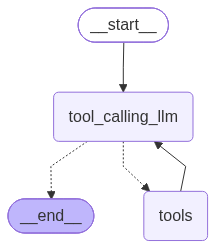

In [51]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [52]:
message = graph.invoke({"messages": "Hi My name is Shahzaib and please tell me recent AI news?"})
for m in message['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi My name is Shahzaib and please tell me recent AI news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_f6e844cb-c692-46dc-9e65-4fb720ced6a0)
 Call ID: fc_f6e844cb-c692-46dc-9e65-4fb720ced6a0
  Args:
    query: latest AI news September 2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News Briefs BULLETIN BOARD for September 2026 – Radical Data Science", "url": "https://radicaldatascience.wpcomstaging.com/2026/09/14/ai-news-briefs-bulletin-board-for-september-2026", "content": "[9/9/2026] Anthropic researcher quits, warns AI “could kill all of us by the end of the decade” – AI researcher Jacob Coxon resigned from Anthropic today. He spent the last three years doing pretraining research at both OpenAI and Anthropic. Neither company is acting re